In [14]:
# Import necessary libraries for creating a kth nearest neighbors model
%matplotlib inline
import numpy as np
import pandas as pd
from sklearn import cluster
from sklearn import datasets
from sklearn import metrics
from sklearn import neighbors
from sklearn import preprocessing
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
df = pd.read_csv('yt_dataset_cleaned.csv')
df.tail()

,video_duration,watch_time,liked,commented,subscribed_after,category,device,watch_time_of_day,recommended,clicked,watch_percent
994995,2390,1902.0,0,0,0,Sports,Tablet,Morning,0,0,0.795816
994996,311,311.0,1,0,0,Education,TV,Evening,0,0,1.000000
994997,2472,2472.0,1,0,0,Tech,Tablet,Evening,0,0,1.000000
994998,1725,1725.0,0,0,1,News,Mobile,Night,1,0,1.000000
994999,952,952.0,0,0,0,News,Tablet,Night,1,1,1.000000


## Train/Test Split

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# target variable is subscribed_after
X = pd.get_dummies(df.drop('subscribed_after', axis=1))
y = df['subscribed_after']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Implement KNN Classification

In [24]:
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score, classification_report

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn.fit(X_train_resampled, y_train_resampled)
y_pred = knn.predict(X_test_scaled)
print("KNN Accuracy:", accuracy_score(y_test, y_pred))

KNN Accuracy: 0.6874874371859296


In [25]:
# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.71      0.81    189034
           1       0.05      0.29      0.09      9966

    accuracy                           0.69    199000
   macro avg       0.50      0.50      0.45    199000
weighted avg       0.90      0.69      0.78    199000



## Confusion Matrix

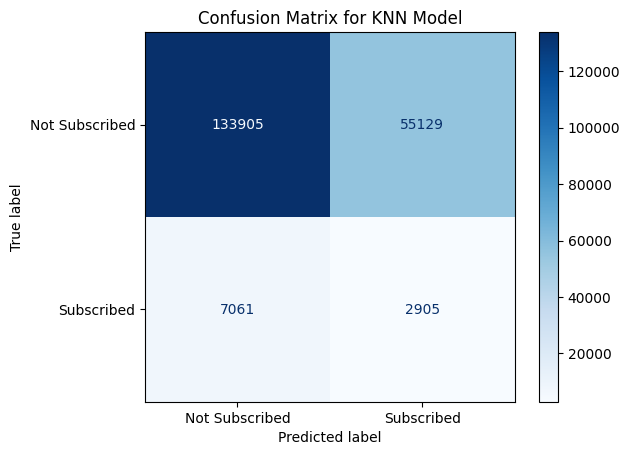

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Subscribed', 'Subscribed'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for KNN Model')
plt.show()